# CMIP Projections

The 5 parameter sets calculkated in Calibration_HBV.ipynb will be used for a validation period, in which the log NSE will be calculated, a mean will be calculated and total low flow days during the navigation season.

The structure of this notebook is as follows:

### 1. Startup
### 2. Model setup
### 3. Running model
### 4. Lowflow calculation

## 1. Startup

In [54]:
# Imports

# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from scipy.interpolate import interp1d

# Niceties
from rich import print

In [55]:
# General eWaterCycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

In [56]:
# Defining things

basin_size = 132572
q_critical = 500

start_year = 2025
end_year = 2050

# Choose CMIP Scenario: 
# Scenario = "ssp126"    # Options: historical, ssp119, ssp126, ssp245, ssp,370, ssp585
# Scenario = {"ssp126", "ssp245", "ssp370"}

In [57]:
scenarios = ["ssp126", "ssp245", "ssp370"]

periods = [
    [2025, 2050, 2075],
    [2050, 2075, 2099]
]

In [58]:
# for i in range(len(scenario)):
#     Scenario = scenario[i]
#     for i in range(len(periods[0])):
#         start_year = periods[0][i]
#         end_year = periods[0][i]

        

In [59]:
# Create pathways for ERA 5 forcings

def forcing_path_cmip(scenario, start_year, end_year):
    
    forcing_path = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "forcings" / "CMIP6" / scenario / f"CMIP6-{start_year}-{end_year}"
    
    return forcing_path

shape_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "Shapefiles" / "07DA001_basin.shp"

hbv_config = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "hbv_config"
hbv_config.mkdir(parents=True, exist_ok=True)

In [60]:
# Adjust time period

validation_start = f"{start_year}-01-01T00:00:00Z"
validation_end = f"{end_year}-12-31T00:00:00Z"

# Define time period
validation_start_date = pd.to_datetime(validation_start.replace("Z", ""))
validation_end_date = pd.to_datetime(validation_end.replace("Z", ""))

# Skip 1 year for filling storages
evaluation_start = pd.to_datetime(f"{validation_start_date.year + 1}-01-01")

### Load CMIP data

In [61]:
# Load data
CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_path_CMIP)

print(CMIP_forcing)

LumpedMakkinkForcing(
    start_time='2025-01-01T00:00:00Z',
    end_time='2050-12-31T00:00:00Z',
    directory=PosixPath('/home/maxime/BEP-maxime/book/thesis_projects/BSc/2026_Q4_MaximedeBekker_CEG/Workyard/forci
ngs/CMIP6/ssp126/CMIP6-2025-2050'),
    shape=PosixPath('/home/maxime/BEP-maxime/book/thesis_projects/BSc/2026_Q4_MaximedeBekker_CEG/Workyard/Shapefile
s/07DA001_basin.shp'),
    filenames={
        'evspsblpot': 'combined_CMIP6_2025_2050_evspsblpot.nc',
        'pr': 'combined_CMIP6_2025_2050_pr.nc',
        'rsds': 'combined_CMIP6_2025_2050_rsds.nc',
        'tas': 'combined_CMIP6_2025_2050_tas.nc'
    }
)

## 2. Model setup

### Load parameter sets & initial storages

In [62]:
# Define parameter ensemble

par_ensemble = [
    [6.279135, 0.4808243, 174.127749, 1.9527195, 0.3305087, 6.19919, 0.0768362, 0.004366398, 0.4076606],
    [7.35776, 0.432509, 192.67085, 1.66088, 0.289296, 5.323766, 0.037268, 0.004399, 1.146504],
    [7.9355, 0.4593, 219.6962, 1.72624, 0.26391, 5.810765, 0.04804, 0.0155065, 0.76857],
    [5.5464, 0.46496, 187.8548, 1.82803, 0.440628, 6.29496, 0.062766, 0.033095, 0.80392],
   [7.23868, 0.47495, 181.82012, 1.8232, 0.4884032, 5.546412, 0.0449439, 0.00231717, 1.25052]
]


par_names = ["Imax",         # Maximum interception storage
               "Ce",         # Evaporation correction factor
               "Sumax",      # Maximum soil moisture storage
               "Beta",       # Soil runoff parameter
               "Pmax",       # Maximum percolation rate
               "Tlag",       # Time lag
               "Kf",         # Fast reservoir recession coefficient
               "Ks",         # Slow reservoir recession coefficient
               "FM"          # Snowmelt factor
               ]

In [63]:
# Define initial storages

#               Si,  Su, Sf, Ss, Sp
s_0 = np.array([0,  100,  0,  5,  0])

### Config model 

In [64]:
# Model setup create function

def run_hbv(parameters, initial_storages, forcing):

    # Creating model object
    model = ewatercycle.models.HBV(forcing=forcing)

    # Creating config file
    config_file, _ = model.setup(
        parameters=parameters,
        initial_storages=initial_storages,
        cfg_dir=hbv_config
    )

    # Initialising model
    model.initialize(config_file)

    # Define & update outputs
    Q_m = []
    time = []

    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime))

    model.finalize()

    # Convert mm/day to m3/s
    model_output_mmday = pd.Series(
        data=Q_m,
        index=time,
        name="Modelled discharge"
    )

    model_output_m3s = model_output_mmday * basin_size * 1000 / 86400

    return model_output_m3s

## 3. Running model

In [65]:
# Model running create function

def run_hbv_ensemble(par_ensemble, initial_storages, forcing):

    # Define amount of parameter sets
    N = len(par_ensemble)
    
    # Create dataframe to append data to & add column for observed data
    ensemble_data = pd.DataFrame()

    for i in range(N):

        print(f"Running parameter set {i+1}/{N}")

        # Run HBV model for the parameter sets 
        simulated = run_hbv(
            parameters=par_ensemble[i],
            initial_storages=initial_storages,
            forcing=forcing
        )

        # Filter data by day only, not by day & time to prevent alignment issues
        simulated_daily = simulated

        simulated_daily.index = pd.to_datetime(simulated_daily.index).tz_localize(None).normalize()
        simulated_daily.name = f"Set {i+1}"
         
        # Append new column for every parameter set results
        ensemble_data[f"Set {i+1}"] = simulated


    # Add mean of all sets
    ensemble_data["Mean"] = ensemble_data.mean(axis=1)

    return ensemble_data

In [66]:
# # Run model functions

# ensemble_data_CMIP = run_hbv_ensemble(
#     par_ensemble=par_ensemble,
#     initial_storages=s_0,
#     forcing=CMIP_forcing
# )

## 4. Lowflow calculation

In [67]:
# # Create low flow counter function

# def lowflow_counter_ensemble(ensemble_data, start_date, end_date):
    
#     lowflow_days = []

#     years = list(range(start_date.year, end_date.year + 1))

#     for i in range(len(years)):
    
#         year = years[i]
    
#         # Define start and end month-day
#         year_start = pd.to_datetime(f"{year}-05-18")
#         year_end = pd.to_datetime(f"{year}-10-17")
    
#         year_data = ensemble_data[
#             (ensemble_data.index >= year_start) &
#             (ensemble_data.index <= year_end)
#         ]

#         # Set zeros to count from
#         modelled_lowflow_days = []
#         modelmean_lowflow_days = 0

#         # Count modelled lowflow days
#         for j in range(len(par_ensemble)):
#             set_lowflow_days = 0

#             for k in range(len(year_data)):
#                 set_q = year_data.iloc[k][f"Set {j+1}"]

#                 if set_q < q_critical:
#                     set_lowflow_days += 1

#             modelled_lowflow_days.append(set_lowflow_days)

#         setavg_lowflow_days = np.mean(modelled_lowflow_days)
        
#         lowflow_days.append({
#             "year": year,
#             "set_1": modelled_lowflow_days[0],
#             "set_2": modelled_lowflow_days[1],
#             "set_3": modelled_lowflow_days[2],
#             "set_4": modelled_lowflow_days[3],
#             "set_5": modelled_lowflow_days[4],
#             "set_avg": np.round(setavg_lowflow_days)
#         })

#     lowflow_days = pd.DataFrame(lowflow_days)

#     # days_sum = lowflow_days[["observed", "modelmean", "set_1", "set_2", "set_3", "set_4", "set_5", "set_avg"]].sum()

#     # print(days_sum)

#     return lowflow_days

In [68]:
def lowflow_counter_future(ensemble_data, start_date, end_date):

    lowflow_days = []

    years = list(range(start_date.year, end_date.year + 1))

    for i in range(len(years)):

        year = years[i]

        year_start = pd.to_datetime(f"{year}-05-18")
        year_end = pd.to_datetime(f"{year}-10-17")

        year_data = ensemble_data[
            (ensemble_data.index >= year_start) &
            (ensemble_data.index <= year_end)
        ]

        modelled_lowflow_days = []

        # Count parameter set low-flow days
        for j in range(len(par_ensemble)):

            set_lowflow_days = 0

            for k in range(len(year_data)):

                set_q = year_data.iloc[k][f"Set {j+1}"]

                if set_q < q_critical:
                    set_lowflow_days += 1

            modelled_lowflow_days.append(set_lowflow_days)

        setavg_lowflow_days = np.mean(modelled_lowflow_days)

        lowflow_days.append({
            "year": year,
            "set_1": modelled_lowflow_days[0],
            "set_2": modelled_lowflow_days[1],
            "set_3": modelled_lowflow_days[2],
            "set_4": modelled_lowflow_days[3],
            "set_5": modelled_lowflow_days[4],
            "set_avg": np.round(setavg_lowflow_days)
        })

    lowflow_days = pd.DataFrame(lowflow_days)

    return lowflow_days

In [69]:
def run_cmip_projection(scenario, start_year, end_year):

    print(f"Running {scenario}, {start_year}-{end_year}")

    forcing_path_CMIP = forcing_path_cmip(
        scenario=scenario,
        start_year=start_year,
        end_year=end_year
    )

    CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_path_CMIP)

    ensemble_data_CMIP = run_hbv_ensemble(
        par_ensemble=par_ensemble,
        initial_storages=s_0,
        forcing=CMIP_forcing
    )

    start_date = pd.to_datetime(f"{start_year + 1}-01-01")
    end_date = pd.to_datetime(f"{end_year}-12-31")

    lowflow_CMIP = lowflow_counter_future(
        ensemble_data=ensemble_data_CMIP,
        start_date=start_date,
        end_date=end_date
    )

    result = {
        "scenario": scenario,
        "period": f"{start_year + 1}-{end_year}",
        "start_year": start_year + 1,
        "end_year": end_year,
        "mean_lowflow_days": lowflow_CMIP["set_avg"].mean(),
        "total_lowflow_days": lowflow_CMIP["set_avg"].sum(),
        "set_1_avg": lowflow_CMIP["set_1"].mean(),
        "set_2_avg": lowflow_CMIP["set_2"].mean(),
        "set_3_avg": lowflow_CMIP["set_3"].mean(),
        "set_4_avg": lowflow_CMIP["set_4"].mean(),
        "set_5_avg": lowflow_CMIP["set_5"].mean(),
    }

    return result, lowflow_CMIP, ensemble_data_CMIP

In [70]:
projection_results = []
lowflow_results = {}
ensemble_results = {}

for i in range(len(scenarios)):

    scenario = scenarios[i]

    for j in range(len(periods[0])):

        start_year = periods[0][j]
        end_year = periods[1][j]

        result, lowflow_CMIP, ensemble_data_CMIP = run_cmip_projection(
            scenario=scenario,
            start_year=start_year,
            end_year=end_year
        )

        projection_results.append(result)

        key = f"{scenario}_{start_year + 1}_{end_year}"

        lowflow_results[key] = lowflow_CMIP
        ensemble_results[key] = ensemble_data_CMIP

Running ssp126, 2025-2050

Running parameter set 1/5

Running parameter set 2/5

Running parameter set 3/5

Running parameter set 4/5

...

Running parameter set 1/5

Running parameter set 2/5

Running parameter set 3/5

Running parameter set 4/5

Running parameter set 5/5

In [71]:
projection_table = pd.DataFrame(projection_results)

projection_table

,scenario,period,start_year,end_year,mean_lowflow_days,total_lowflow_days,set_1_avg,set_2_avg,set_3_avg,set_4_avg,set_5_avg
0,ssp126,2026-2050,2026,2050,34.800000,870.0,46.360000,30.400000,35.560000,39.200000,22.280000
1,ssp126,2051-2075,2051,2075,38.520000,963.0,50.160000,35.280000,39.040000,42.640000,26.320000
2,ssp126,2076-2099,2076,2099,32.333333,776.0,43.916667,28.916667,33.750000,34.875000,19.666667
3,ssp245,2026-2050,2026,2050,41.640000,1041.0,50.600000,37.640000,42.280000,45.200000,32.720000
4,ssp245,2051-2075,2051,2075,35.040000,876.0,44.960000,31.920000,35.200000,37.000000,26.000000
5,ssp245,2076-2099,2076,2099,28.500000,684.0,38.708333,24.250000,29.958333,32.458333,17.166667
6,ssp370,2026-2050,2026,2050,35.080000,877.0,44.200000,31.400000,37.120000,38.840000,23.920000
7,ssp370,2051-2075,2051,2075,46.960000,1174.0,58.120000,43.520000,49.320000,53.640000,30.520000
8,ssp370,2076-2099,2076,2099,49.000000,1176.0,60.375000,43.875000,49.291667,55.541667,35.666667


In [73]:
projection_table = pd.DataFrame(projection_results)

summary_table = projection_table.pivot(
    index="scenario",
    columns="period",
    values="mean_lowflow_days"
)

summary_table

period,2026-2050,2051-2075,2076-2099
scenario,,,
ssp126,34.80,38.52,32.333333
ssp245,41.64,35.04,28.500000
ssp370,35.08,46.96,49.000000


# 5. Compare forcing inputs 

In [95]:
def find_file_for_var(folder, var_name):

    folder = Path(folder)

    # First try exact final variable pattern, then broader search
    matches = list(folder.glob(f"*_{var_name}.nc"))

    if len(matches) == 0:
        matches = list(folder.glob(f"*{var_name}*.nc"))

    if len(matches) == 0:
        raise FileNotFoundError(f"No NetCDF file found for {var_name} in {folder}")

    if len(matches) > 1:
        print(f"Multiple files found for {var_name}, using first:")
        for match in matches:
            print(" -", match.name)

    return matches[0]



def get_dataarray(dataset, preferred_name):

    if preferred_name in dataset.data_vars:
        return dataset[preferred_name]

    first_var = list(dataset.data_vars)[0]
    print(f"Variable {preferred_name} not found, using {first_var} instead.")
    return dataset[first_var]


def load_variable(folder, var_name):

    file_path = find_file_for_var(folder, var_name)

    ds = xr.open_dataset(file_path)
    da = get_dataarray(ds, var_name).squeeze()
    
        # Normalize daily time coordinate: removes 11:30 / 12:00 differences
    da = da.assign_coords(time=pd.to_datetime(da.time.values).normalize())

    if "time" not in da.dims:
        raise ValueError(f"{file_path} does not contain a time dimension.")

    return da, ds, file_path

def to_series(da):
    return pd.Series(
        data=da.values.squeeze(),
        index=pd.to_datetime(da["time"].values),
        name=da.name,
    )


In [96]:
def forcing_summary_period(scenario, start_year, end_year):

    forcing_path = forcing_path_cmip(scenario, start_year, end_year)

    variables = ["pr", "tas", "rsds", "evspsblpot"]
    rows = []

    for var_name in variables:

        da, _, _ = load_variable(forcing_path, var_name)
        s = to_series(da)

        if var_name in ["pr", "evspsblpot"]:
            s = s * 86400
            value = s.sum() / (end_year - start_year + 1)
            stat = "mean annual sum mm/year"

        elif var_name == "tas":
            s = s - 273.15
            value = s.mean()
            stat = "mean °C"

        elif var_name == "rsds":
            value = s.mean()
            stat = "mean W/m²"

        rows.append({
            "scenario": scenario,
            "period": f"{start_year}-{end_year}",
            "variable": var_name,
            "statistic": stat,
            "value": value
        })

    return pd.DataFrame(rows)

In [101]:
forcing_summaries = []

for scenario in scenarios:

    for i in range(len(periods[0])):

        start_year = periods[0][i]
        end_year = periods[1][i]

        forcing_summaries.append(
            forcing_summary_period(scenario, start_year, end_year)
        )

forcing_summary_table = pd.concat(forcing_summaries, ignore_index=True)

In [102]:
forcing_summary_pivot = forcing_summary_table.pivot_table(
    index=["scenario", "period"],
    columns="variable",
    values="value"
)

forcing_summary_pivot

variable            evspsblpot          pr        rsds       tas
scenario period                                                 
ssp126   2025-2050  621.115827  633.866016  138.530518  2.507785
         2050-2075  625.834602  630.108168  138.729980  2.994848
         2075-2099  621.526396  645.313406  138.176804  2.738721
ssp245   2025-2050  628.019652  622.963642  139.454956  2.663425
         2050-2075  632.682703  637.349485  138.314972  3.588089
         2075-2099  635.643577  659.815115  137.841309  3.646670
ssp370   2025-2050  623.396508  640.490159  138.547470  2.715807
         2050-2075  636.281969  650.255712  136.660095  4.362177
         2075-2099  656.929423  645.734789  136.637268  5.423460

# 6. CDF

In [123]:
def plot_lowflow_cdf_by_scenario(lowflow_results, scenarios, periods):

    plt.figure(figsize=(8, 5))

    for scenario in scenarios:

        all_lowflows = []

        for i in range(len(periods[0])):

            start_year = periods[0][i]
            end_year = periods[1][i]

            key = f"{scenario}_{start_year}_{end_year}"

            lowflow_table = lowflow_results[key]

            all_lowflows.extend(lowflow_table["set_avg"].values)

        values = np.sort(all_lowflows)
        cdf = np.arange(1, len(values) + 1) / len(values)

        plt.plot(
            values,
            cdf,
            marker="o",
            label=scenario
        )

    plt.xlabel("Annual low-flow days")
    plt.ylabel("Cumulative probability")
    plt.title("CDF of annual low-flow days by SSP scenario")
    plt.grid(True)
    plt.legend()
    plt.show()

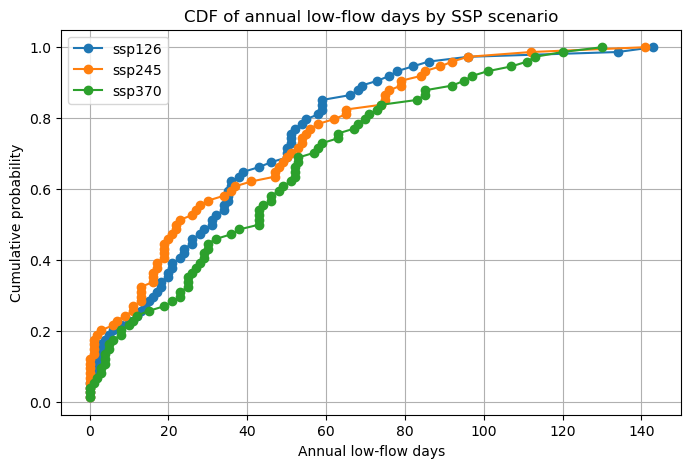

In [124]:
periods = [
    [2026, 2051, 2076],
    [2050, 2075, 2099]
]

plot_lowflow_cdf_by_scenario(
    lowflow_results=lowflow_results,
    scenarios=scenarios,
    periods=periods
)

In [125]:
def plot_lowflow_exceedance_by_scenario(lowflow_results, scenarios, periods):

    plt.figure(figsize=(8, 5))

    for scenario in scenarios:

        all_lowflows = []

        for i in range(len(periods[0])):

            start_year = periods[0][i]
            end_year = periods[1][i]

            key = f"{scenario}_{start_year}_{end_year}"
            lowflow_table = lowflow_results[key]

            all_lowflows.extend(lowflow_table["set_avg"].values)

        values = np.sort(all_lowflows)
        exceedance = 1 - (np.arange(1, len(values) + 1) / len(values))

        plt.plot(values, exceedance, marker="o", label=scenario)

    plt.xlabel("Annual low-flow days")
    plt.ylabel("Exceedance probability")
    plt.title("Exceedance probability of annual low-flow days")
    plt.grid(True)
    plt.legend()
    plt.show()

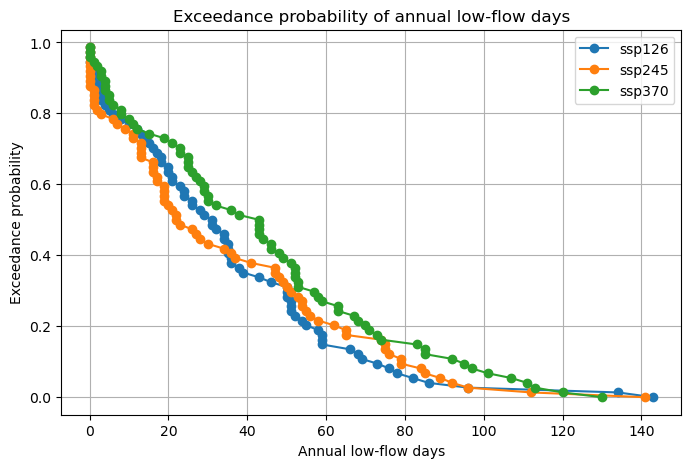

In [126]:
plot_lowflow_exceedance_by_scenario(lowflow_results, scenarios, periods)

In [129]:
def boxplot_lowflow_by_scenario(lowflow_results, scenarios, periods):

    data = []
    labels = []

    for scenario in scenarios:

        all_lowflows = []

        for i in range(len(periods[0])):

            start_year = periods[0][i]
            end_year = periods[1][i]

            key = f"{scenario}_{start_year}_{end_year}"
            lowflow_table = lowflow_results[key]

            all_lowflows.extend(lowflow_table["set_avg"].values)

        data.append(all_lowflows)
        labels.append(scenario)

    plt.figure(figsize=(7, 5))
    plt.boxplot(data, labels=labels)
    plt.ylabel("Annual low-flow days")
    plt.title("Distribution of annual low-flow days by SSP scenario")
    plt.grid(True)
    plt.show()

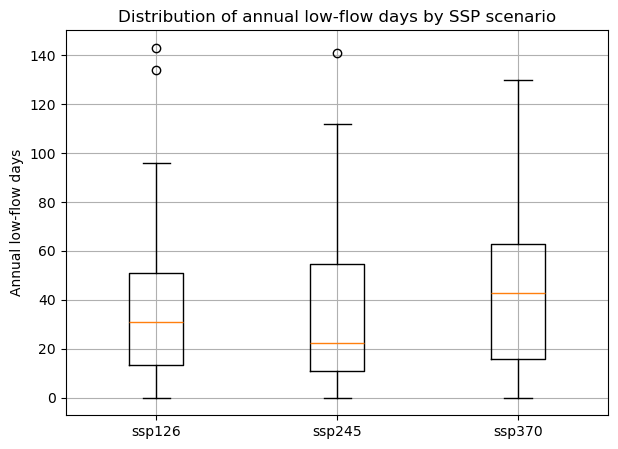

In [130]:
boxplot_lowflow_by_scenario(lowflow_results, scenarios, periods)

In [133]:
def lowflow_quantile_table(lowflow_results, scenarios, periods):

    rows = []

    for scenario in scenarios:

        all_lowflows = []

        for i in range(len(periods[0])):

            start_year = periods[0][i]
            end_year = periods[1][i]

            key = f"{scenario}_{start_year}_{end_year}"
            lowflow_table = lowflow_results[key]

            all_lowflows.extend(lowflow_table["set_avg"].values)

        values = pd.Series(all_lowflows)

        rows.append({
            "scenario": scenario,
            "mean": values.mean(),
            "median": values.median(),
            "p75": values.quantile(0.75),
            "p90": values.quantile(0.90),
            "max": values.max()
        })

    return pd.DataFrame(rows)

In [134]:
lowflow_quantile_table(lowflow_results, scenarios, periods)

,scenario,mean,median,p75,p90,max
0,ssp126,35.256757,31.0,51.00,71.8,143.0
1,ssp245,35.148649,22.5,54.75,79.0,141.0
2,ssp370,43.608108,43.0,63.00,94.1,130.0


# 7. Algorithm 2

In [115]:
selected_scenario = "ssp370"
start_year = 2075
end_year = 2099
AFDD_critical = 30

In [116]:
forcing_path_CMIP = forcing_path_cmip(
    scenario=selected_scenario,
    start_year=start_year,
    end_year=end_year
)

CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(
    directory=forcing_path_CMIP
)

ensemble_data_CMIP = run_hbv_ensemble(
    par_ensemble=par_ensemble,
    initial_storages=s_0,
    forcing=CMIP_forcing
)

Running parameter set 1/5

Running parameter set 2/5

Running parameter set 3/5

Running parameter set 4/5

Running parameter set 5/5

In [117]:
def find_freshet_start_dates(ensemble_data, start_year, end_year):

    freshet_dates = []

    for year in range(start_year, end_year + 1):

        year_start = pd.to_datetime(f"{year}-03-01")
        year_end = pd.to_datetime(f"{year}-08-01")

        season_data = ensemble_data[
            (ensemble_data.index >= year_start) &
            (ensemble_data.index <= year_end)
        ]

        above_critical = season_data[season_data["Mean"] > q_critical]

        if len(above_critical) > 0:
            freshet_date = above_critical.index[0]
            discharge = above_critical.iloc[0]["Mean"]
        else:
            freshet_date = pd.NaT
            discharge = np.nan

        freshet_dates.append({
            "year": year,
            "freshet_start": freshet_date,
            "freshet_discharge": discharge
        })

    return pd.DataFrame(freshet_dates)

In [118]:
def find_freezeup_dates(forcing_path, start_year, end_year, AFDD_critical=30):

    tas_da, _, _ = load_variable(forcing_path, "tas")

    tas = to_series(tas_da)

    if tas.mean() > 100:
        tas = tas - 273.15

    freezeup_dates = []

    for year in range(start_year, end_year + 1):

        year_start = pd.to_datetime(f"{year}-10-01")
        year_end = pd.to_datetime(f"{year}-12-31")

        year_tas = tas[
            (tas.index >= year_start) &
            (tas.index <= year_end)
        ]

        AFDD = 0
        freezeup_date = pd.NaT
        freezeup_temp = np.nan

        for date, temp in year_tas.items():

            if temp < 0:
                AFDD += -temp

            if AFDD >= AFDD_critical:
                freezeup_date = date
                freezeup_temp = temp
                break

        freezeup_dates.append({
            "year": year,
            "freezeup_date": freezeup_date,
            "AFDD": AFDD,
            "temp_at_freezeup": freezeup_temp
        })

    return pd.DataFrame(freezeup_dates)

In [119]:
freshet_dates = find_freshet_start_dates(
    ensemble_data=ensemble_data_CMIP,
    start_year=start_year,
    end_year=end_year
)

freezeup_dates = find_freezeup_dates(
    forcing_path=forcing_path_CMIP,
    start_year=start_year,
    end_year=end_year,
    AFDD_critical=AFDD_critical
)

open_water_dates = freshet_dates.merge(
    freezeup_dates,
    on="year",
    how="inner"
)

open_water_dates["open_water_days"] = (
    open_water_dates["freezeup_date"] - open_water_dates["freshet_start"]
).dt.days

open_water_dates

,year,freshet_start,freshet_discharge,freezeup_date,AFDD,temp_at_freezeup,open_water_days
0,2075,2075-04-21,519.219346,2075-11-19,35.262756,-8.498932,212
1,2076,2076-03-24,520.049117,2076-11-21,39.384277,-9.844208,242
2,2077,2077-03-29,546.557068,2077-11-10,32.923767,-5.950165,226
3,2078,2078-04-07,514.114383,2078-10-22,30.640839,-5.857758,198
4,2079,2079-03-30,510.619604,2079-11-27,33.224365,-5.251129,242
5,2080,2080-04-01,569.975708,2080-11-23,37.704834,-8.989227,236
6,2081,2081-04-01,542.075464,2081-11-16,30.076477,-5.813904,229
7,2082,2082-04-07,538.807757,2082-10-26,30.872345,-7.023956,202
8,2083,2083-04-20,504.327828,2083-11-11,40.646301,-12.157623,205
9,2084,2084-04-01,534.445682,2084-11-15,31.272736,-2.706055,228
